# AML Sentinel — Explainable AI (XAI)
### SHAP + Qwen 2.5 1.5B Transaction Explanations
- **Cell 1:** Imports & Load Models
- **Cell 2:** Load Test Data & Select Cases
- **Cell 3:** Compute SHAP Values
- **Cell 4:** Load Qwen 2.5 1.5B
- **Cell 5:** Generate Explanations
- **Cell 6:** Save Reports

In [1]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Cell 1: Imports & Load Models                              ║
# ╚══════════════════════════════════════════════════════════════╝
import sys
import os
import json
import warnings
warnings.filterwarnings('ignore')

import importlib
sys.path.insert(0, r'C:\Users\VatsaL\Desktop\Datasets\AML_Sentinel')
import config
importlib.reload(config)
from config import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import xgboost as xgb
import lightgbm as lgb
import torch

# ── Load ensemble weights ──────────────────────────────────────
weights_path = os.path.join(MODELS_DIR, 'ensemble_weights.json')
with open(weights_path, 'r') as f:
    weights = json.load(f)

feature_cols = weights['feature_cols']
threshold    = weights['threshold']
xgb_weight   = weights['xgb_weight']
lgb_weight   = weights['lgb_weight']

# ── Load models ────────────────────────────────────────────────
print('📦 Loading XGBoost model...')
xgb_model = xgb.XGBClassifier()
xgb_model.load_model(XGB_MODEL)

print('📦 Loading LightGBM model...')
lgb_booster = lgb.Booster(model_file=LGB_MODEL)

print(f'\n✅ Models loaded!')
print(f'   Features   : {len(feature_cols)}')
print(f'   Threshold  : {threshold}')
print(f'   XGB weight : {xgb_weight:.4f}')
print(f'   LGB weight : {lgb_weight:.4f}')
print(f'   Device     : {"CUDA" if torch.cuda.is_available() else "CPU"}')

📦 Loading XGBoost model...
📦 Loading LightGBM model...

✅ Models loaded!
   Features   : 18
   Threshold  : 0.8514
   XGB weight : 0.5000
   LGB weight : 0.5000
   Device     : CUDA


In [2]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Cell 2: Load Test Data & Select Cases                      ║
# ╚══════════════════════════════════════════════════════════════╝
print('📥 Loading features_final.parquet...')

spark = get_spark_session('AML_XAI')
from pyspark.sql.functions import col

df = spark.read.parquet(FEATURES_FINAL_PARQUET)

null_fill_map = {
    'fan_in_degree': 0, 'fan_out_degree': 0,
    'tx_velocity': 1, 'amount_per_tx': 0,
    'amount_zscore_per_bank': 0, 'bank_risk_score': 0,
    'is_high_fan_out': 0, 'is_in_cycle': 0, 'is_hub_bank': 0
}
df = df.fillna(null_fill_map)

# ── Recreate test set (same split as training) ─────────────────
laundering_df = df.filter(col('Is Laundering') == 1)
legit_df      = df.filter(col('Is Laundering') == 0)
_, test_laund = laundering_df.randomSplit([0.8, 0.2], seed=42)
_, test_legit = legit_df.randomSplit([0.8, 0.2], seed=42)
test_df = test_laund.union(test_legit)

select_cols = feature_cols + ['Is Laundering', 'Amount Paid', 'From Bank',
                               'To Bank', 'Payment Format', 'Payment Currency']
select_cols = [c for c in select_cols if c in df.columns]

test_pd = test_df.select(select_cols).toPandas()
spark.stop()

# ── Get ensemble scores ────────────────────────────────────────
X_test = test_pd[feature_cols].values.astype(np.float32)
y_test = test_pd['Is Laundering'].values

xgb_probs      = xgb_model.predict_proba(X_test)[:, 1]
lgb_probs      = lgb_booster.predict(X_test)
ensemble_probs = xgb_weight * xgb_probs + lgb_weight * lgb_probs
y_pred         = (ensemble_probs >= threshold).astype(int)

# ── Select 10 TP, 10 FP, 10 FN ────────────────────────────────
tp_mask = (y_pred == 1) & (y_test == 1)
fp_mask = (y_pred == 1) & (y_test == 0)
fn_mask = (y_pred == 0) & (y_test == 1)

np.random.seed(42)
tp_idx = np.where(tp_mask)[0][:10]
fp_idx = np.where(fp_mask)[0][:10]
fn_idx = np.where(fn_mask)[0][:10]

print(f'\n✅ Test set loaded: {len(test_pd):,} rows')
print(f'   True Positives  (correctly flagged fraud) : {tp_mask.sum():,}')
print(f'   False Positives (wrongly flagged legit)   : {fp_mask.sum():,}')
print(f'   False Negatives (missed fraud)            : {fn_mask.sum():,}')
print(f'\n   Selected for XAI:')
print(f'   10 TP + 10 FP + 10 FN = 30 transactions')

📥 Loading features_final.parquet...

✅ Test set loaded: 6,380,255 rows
   True Positives  (correctly flagged fraud) : 5,599
   False Positives (wrongly flagged legit)   : 87,716
   False Negatives (missed fraud)            : 1,294

   Selected for XAI:
   10 TP + 10 FP + 10 FN = 30 transactions


🔍 Computing SHAP values...
✅ SHAP values computed for 30 transactions
   Shape: (30, 18)


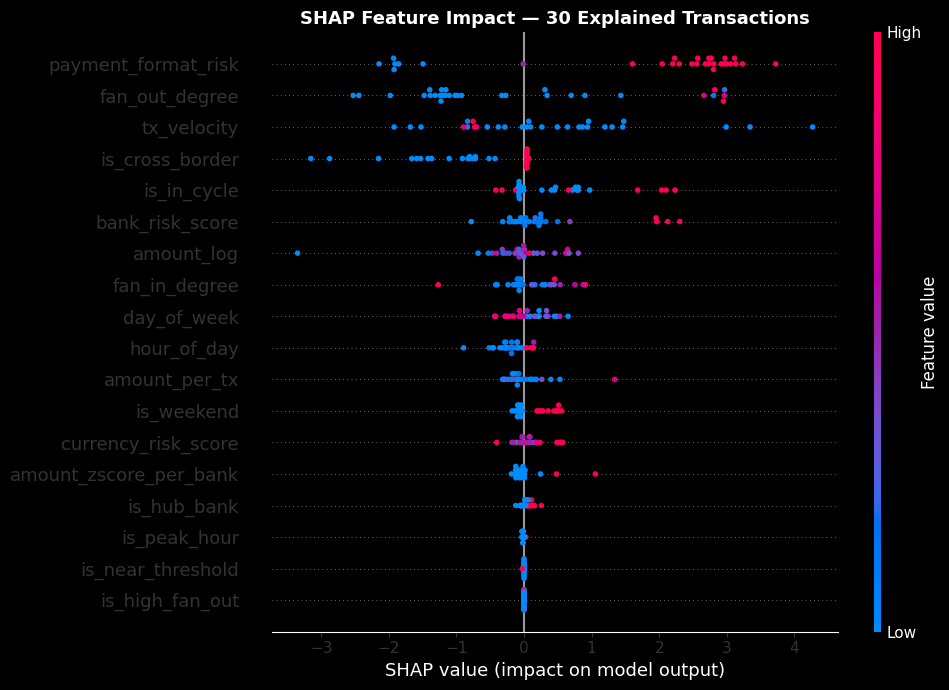

✅ SHAP plot saved to C:\Users\VatsaL\Desktop\Datasets\AML_Sentinel\training_outputs\shap_summary.png
✅ SHAP helper functions ready


In [3]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Cell 3: Compute SHAP Values                                ║
# ╚══════════════════════════════════════════════════════════════╝
print('🔍 Computing SHAP values...')

# Combine all 30 cases
all_idx      = np.concatenate([tp_idx, fp_idx, fn_idx])
all_labels   = (['TP'] * len(tp_idx) +
                ['FP'] * len(fp_idx) +
                ['FN'] * len(fn_idx))
X_explain    = X_test[all_idx]
scores_explain = ensemble_probs[all_idx]
actual_explain = y_test[all_idx]

# SHAP on XGBoost (faster + more reliable than LGB for SHAP)
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_explain)

print(f'✅ SHAP values computed for {len(X_explain)} transactions')
print(f'   Shape: {shap_values.shape}')

# ── SHAP Summary Plot ──────────────────────────────────────────
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_explain,
    feature_names=feature_cols,
    show=False, plot_size=None
)
plt.title('SHAP Feature Impact — 30 Explained Transactions',
          fontsize=13, fontweight='bold')
plt.tight_layout()
shap_plot_path = os.path.join(TRAINING_DIR, 'shap_summary.png')
plt.savefig(shap_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ SHAP plot saved to {shap_plot_path}')

# ── Helper: get top SHAP drivers for one transaction ──────────
def get_shap_drivers(shap_row, feature_names, top_n=5):
    """Returns top N features driving the prediction with direction."""
    pairs = list(zip(feature_names, shap_row))
    pairs_sorted = sorted(pairs, key=lambda x: abs(x[1]), reverse=True)
    drivers = []
    for feat, val in pairs_sorted[:top_n]:
        direction = 'increases' if val > 0 else 'decreases'
        drivers.append({
            'feature'  : feat,
            'shap_val' : round(float(val), 4),
            'direction': direction
        })
    return drivers

print('✅ SHAP helper functions ready')

In [4]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Cell 4: Load Qwen 2.5 1.5B (Final — Anti-Hallucination)   ║
# ╚══════════════════════════════════════════════════════════════╝
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import re

MODEL_ID = 'Qwen/Qwen2.5-1.5B-Instruct'

print(f'📦 Loading {MODEL_ID}...')

bnb_config = BitsAndBytesConfig(
    load_in_4bit              = True,
    bnb_4bit_compute_dtype    = torch.float16,
    bnb_4bit_use_double_quant = True,
    bnb_4bit_quant_type       = 'nf4'
)

tokenizer  = AutoTokenizer.from_pretrained(MODEL_ID)
qwen_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config = bnb_config,
    device_map          = 'auto',
    torch_dtype         = torch.float16
)
qwen_model.eval()

print(f'\n✅ Qwen 2.5 1.5B loaded!')
print(f'   VRAM used: {torch.cuda.memory_allocated()/1e9:.2f} GB')
print(f'   Device   : {next(qwen_model.parameters()).device}')

# ── Helper: convert amount_log to approximate real amount ─────
def approx_amount(amount_log):
    real = round(pow(2.718, float(amount_log)) - 1, 0)
    if real < 1000:
        return f"small (~${real:,.0f})"
    elif real < 10000:
        return f"moderate (~${real:,.0f})"
    elif real < 100000:
        return f"large (~${real:,.0f})"
    else:
        return f"very large (~${real:,.0f})"

# ── Helper: decode payment format ────────────────────────────
def decode_payment_format(risk_score):
    mapping = {3: "ACH", 2: "Bitcoin", 1: "Cash/Cheque/Credit Card", 0: "Wire/Reinvestment"}
    return mapping.get(int(float(risk_score)), "Unknown")

# ── Helper: post-processing validation ───────────────────────
def validate_explanation(explanation, transaction_info):
    issues = []

    # Dollar amount hallucination — any specific dollar figure
    dollar_mentions = re.findall(r'\$[\d,]{5,}', explanation)
    if dollar_mentions:
        issues.append(f"hallucinated dollar amounts: {dollar_mentions}")

    # Per-hour / per-minute hallucination
    if 'per hour' in explanation.lower() or 'per minute' in explanation.lower():
        issues.append("tx_velocity described as rate (per hour/min) — it is lifetime total")

    # Structuring mentioned when is_near_threshold=0
    if (float(transaction_info.get('is_near_threshold', 0)) == 0 and
            'structur' in explanation.lower()):
        issues.append("structuring mentioned but is_near_threshold=0")

    # Cross-border mentioned when is_cross_border=0
    if (float(transaction_info.get('is_cross_border', 0)) == 0 and
            'cross-border' in explanation.lower()):
        issues.append("cross-border mentioned but is_cross_border=0")

    # Circular/cycle mentioned when is_in_cycle=0
    if (float(transaction_info.get('is_in_cycle', 0)) == 0 and
            'circular' in explanation.lower()):
        issues.append("circular pattern mentioned but is_in_cycle=0")

    return issues

# ── Case context ──────────────────────────────────────────────
case_context_map = {
    'TP': (
        "CORRECTLY FLAGGED — CONFIRMED FRAUD",
        "Explain clearly why this transaction is suspicious. "
        "Reference specific feature values from the facts below. "
        "Do NOT raise doubt about the verdict."
    ),
    'FP': (
        "INCORRECTLY FLAGGED — CONFIRMED LEGITIMATE",
        "Explain why the model wrongly flagged this legitimate transaction. "
        "Identify which features look suspicious but have innocent explanations. "
        "Do NOT say it should be flagged — it is confirmed legitimate."
    ),
    'FN': (
        "MISSED FRAUD — MODEL FAILED TO DETECT",
        "Explain why the model missed this real fraud case. "
        "Identify which features should have triggered a flag but did not. "
        "Be specific about what pattern an investigator should look for manually."
    )
}

# ── Main explanation generator ────────────────────────────────
def generate_explanation(transaction_info, shap_drivers, case_type, max_new_tokens=500):
    """
    Final version — constrained template + explicit prohibitions +
    pre-processed features + temperature 0.1 + post-processing validator
    """
    verdict_label, case_instruction = case_context_map[case_type]

    # Pre-process ALL features before sending to Qwen
    # This prevents the model from doing any math or conversion
    payment_name  = decode_payment_format(transaction_info.get('payment_format_risk', 0))
    amount_label  = approx_amount(transaction_info.get('amount_log', 0))
    fan_out       = int(transaction_info.get('fan_out_degree', 0))
    fan_in        = int(transaction_info.get('fan_in_degree', 0))
    tx_vel        = int(transaction_info.get('tx_velocity', 0))
    bank_risk     = float(transaction_info.get('bank_risk_score', 0))
    cross_border  = transaction_info.get('is_cross_border', 0) == 1
    in_cycle      = transaction_info.get('is_in_cycle', 0) == 1
    near_thresh   = transaction_info.get('is_near_threshold', 0) == 1

    # Build pre-decoded facts — NO raw numbers that Qwen might misinterpret
    facts = f"""Payment method    : {payment_name} (risk={int(float(transaction_info.get('payment_format_risk',0)))}/3, higher=riskier)
Transaction size  : {amount_label} [DO NOT convert this to a specific dollar figure]
Unique receivers  : {fan_out} different accounts received from this sender
Unique senders    : {fan_in} different accounts sent to this receiver
Lifetime tx count : {tx_vel} total transactions (this is a LIFETIME count, NOT per hour)
Bank risk score   : {bank_risk:.4f} out of 1.0 (higher means bank has more laundering history)
Cross-border      : {'YES — transaction crosses bank boundaries' if cross_border else 'NO — same bank transaction'}
Circular pattern  : {'YES — A sends to B, B sends back to A' if in_cycle else 'NO — no circular pattern detected'}
Near $8K-$10K     : {'YES — possible structuring attempt' if near_thresh else 'NO — not in structuring range'}"""

    # Format SHAP drivers — only meaningful ones
    drivers_lines = []
    for d in shap_drivers:
        if abs(d['shap_val']) > 0.05:
            arrow = "INCREASES" if d['shap_val'] > 0 else "DECREASES"
            drivers_lines.append(
                f"  {d['feature']:<28} {arrow} fraud risk  (SHAP={d['shap_val']:+.4f})"
            )
    drivers_text = '\n'.join(drivers_lines)

    system_prompt = f"""You are a professional AML (Anti-Money Laundering) compliance analyst.
Write structured transaction risk reports for compliance officers and financial investigators.

STRICT RULES — follow every rule without exception:
1. Use ONLY the transaction facts provided — do not invent any values
2. The transaction size is given as a range label — do NOT write a specific dollar amount
3. Lifetime tx count means total transactions ever — NEVER say 'per hour' or 'per minute'
4. If Cross-border says NO — do not mention cross-border at all
5. If Circular pattern says NO — do not mention circular or cycle patterns at all
6. If Near $8K-$10K says NO — do not mention structuring at all
7. Do NOT start your response with 'This transaction'
8. Fill the template exactly — do not echo back the instructions
9. Maximum 5 sentences total across all sections"""

    user_prompt = f"""CASE: {verdict_label}
RISK SCORE: {transaction_info['score']:.4f} | THRESHOLD: {threshold}
INSTRUCTION: {case_instruction}

TRANSACTION FACTS:
{facts}

SHAP ANALYSIS (what drove the model decision):
{drivers_text}

Fill in ONLY this template — do not add any other sections:

ALERT STATUS: [write FLAGGED or CLEARED and one-phrase reason]

PRIMARY CONCERN: [one sentence — most important risk driver based on SHAP]

SUPPORTING EVIDENCE: [two sentences — reference specific facts from above]

INVESTIGATOR NOTE: [one sentence — specific actionable recommendation]"""

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user",   "content": user_prompt}
    ]

    text   = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer([text], return_tensors='pt').to(qwen_model.device)

    with torch.no_grad():
        outputs = qwen_model.generate(
            **inputs,
            max_new_tokens = max_new_tokens,
            temperature    = 0.1,
            top_p          = 0.85,
            do_sample      = True,
            pad_token_id   = tokenizer.eos_token_id
        )

    generated   = outputs[0][inputs.input_ids.shape[1]:]
    explanation = tokenizer.decode(generated, skip_special_tokens=True).strip()

    # Post-processing validation
    issues = validate_explanation(explanation, transaction_info)
    if issues:
        explanation += f"\n\n⚠️  AUTO-VALIDATION WARNING: {'; '.join(issues)}"

    return explanation

print('✅ Final explanation generator ready!')
print('   Anti-hallucination measures active:')
print('   ✅ Constrained 4-section template')
print('   ✅ 9 explicit prohibition rules')
print('   ✅ All features pre-decoded before prompt')
print('   ✅ amount_log → range label (no raw numbers)')
print('   ✅ Binary flags → YES/NO with context')
print('   ✅ Temperature 0.1 (deterministic)')
print('   ✅ max_new_tokens 500 (no truncation)')
print('   ✅ Post-processing validator with 5 checks')

📦 Loading Qwen/Qwen2.5-1.5B-Instruct...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]


✅ Qwen 2.5 1.5B loaded!
   VRAM used: 1.16 GB
   Device   : cuda:0
✅ Final explanation generator ready!
   Anti-hallucination measures active:
   ✅ Constrained 4-section template
   ✅ 9 explicit prohibition rules
   ✅ All features pre-decoded before prompt
   ✅ amount_log → range label (no raw numbers)
   ✅ Binary flags → YES/NO with context
   ✅ Temperature 0.1 (deterministic)
   ✅ max_new_tokens 500 (no truncation)
   ✅ Post-processing validator with 5 checks


In [5]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Cell 5: Generate Explanations                              ║
# ╚══════════════════════════════════════════════════════════════╝
print('🤖 Generating XAI explanations with Qwen 2.5 1.5B...')
print('   Processing 30 transactions (10 TP + 10 FP + 10 FN)')
print('   Estimated time: 5-10 minutes\n')

all_reports = []
case_types  = ['TP'] * len(tp_idx) + ['FP'] * len(fp_idx) + ['FN'] * len(fn_idx)
case_names  = {
    'TP': 'TRUE POSITIVE  (Correctly Flagged Fraud)',
    'FP': 'FALSE POSITIVE (Wrongly Flagged Legitimate)',
    'FN': 'FALSE NEGATIVE (Missed Fraud)'
}

for i, (idx, case_type) in enumerate(zip(all_idx, case_types)):
    print(f'[{i+1:02d}/30] {case_names[case_type]}...')

    # Build transaction info dict
    row = test_pd.iloc[idx]
    transaction_info = {feat: round(float(row[feat]), 4) for feat in feature_cols}
    transaction_info['score']  = float(scores_explain[i])
    transaction_info['actual'] = int(actual_explain[i])

    # Get SHAP drivers
    shap_drivers = get_shap_drivers(shap_values[i], feature_cols, top_n=5)

    # Generate explanation
    explanation = generate_explanation(transaction_info, shap_drivers, case_type)

    # Build report
    report = {
        'case_id'          : i + 1,
        'case_type'        : case_type,
        'risk_score'       : transaction_info['score'],
        'actual_label'     : transaction_info['actual'],
        'verdict'          : 'FLAGGED' if transaction_info['score'] >= threshold else 'CLEARED',
        'top_shap_drivers' : shap_drivers,
        'features'         : transaction_info,
        'explanation'      : explanation
    }
    all_reports.append(report)

    # Print preview
    print(f'   Score: {transaction_info["score"]:.4f} | Top driver: {shap_drivers[0]["feature"]}')
    print(f'   {explanation[:150]}...')
    print()

print(f'✅ All {len(all_reports)} explanations generated!')

🤖 Generating XAI explanations with Qwen 2.5 1.5B...
   Processing 30 transactions (10 TP + 10 FP + 10 FN)
   Estimated time: 5-10 minutes

[01/30] TRUE POSITIVE  (Correctly Flagged Fraud)...
   Score: 0.9888 | Top driver: payment_format_risk
   **ALERT STATUS:** FLAGGED  
**ONE-PHASE REASON:** High payment format risk, increased due to multiple cycles and high bank risk score.  

**PRIMARY CO...

[02/30] TRUE POSITIVE  (Correctly Flagged Fraud)...
   Score: 0.9897 | Top driver: payment_format_risk
   **ALERT STATUS:** FLAGGED  
**ONE-PHASE REASON:** High payment format risk, increased due to multiple cycles and high bank risk score.  

**PRIMARY CO...

[03/30] TRUE POSITIVE  (Correctly Flagged Fraud)...
   Score: 0.8726 | Top driver: payment_format_risk
   **ALERT STATUS:** FLAGGED  
**ONE-PHASE REASON:** High payment format risk combined with low velocity and high fan-out degree.  

**PRIMARY CONCERN:**...

[04/30] TRUE POSITIVE  (Correctly Flagged Fraud)...
   Score: 0.9927 | Top dri

In [6]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Cell 6: Save Reports                                       ║
# ╚══════════════════════════════════════════════════════════════╝
import json
from datetime import datetime

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
xai_dir   = os.path.join(TRAINING_DIR, 'xai_reports')
os.makedirs(xai_dir, exist_ok=True)

# ── Save JSON (machine readable) ──────────────────────────────
json_path = os.path.join(xai_dir, f'xai_reports_{timestamp}.json')
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(all_reports, f, indent=2, ensure_ascii=False)
print(f'✅ JSON saved : {json_path}')

# ── Save Human Readable TXT ───────────────────────────────────
txt_path = os.path.join(xai_dir, f'xai_reports_{timestamp}.txt')
with open(txt_path, 'w', encoding='utf-8') as f:
    f.write('AML SENTINEL - EXPLAINABLE AI REPORT\n')
    f.write(f'Generated: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}\n')
    f.write(f'Model: XGBoost + LightGBM Ensemble + Qwen 2.5 1.5B\n')
    f.write('=' * 65 + '\n\n')

    for r in all_reports:
        f.write(f"CASE {r['case_id']:02d} — {r['case_type']} — {case_names[r['case_type']]}\n")
        f.write('-' * 65 + '\n')
        f.write(f"Risk Score  : {r['risk_score']:.4f}\n")
        f.write(f"Verdict     : {r['verdict']}\n")
        f.write(f"Actual Label: {'FRAUD' if r['actual_label'] == 1 else 'LEGITIMATE'}\n")
        f.write(f"\nTop SHAP Drivers:\n")
        for d in r['top_shap_drivers']:
            f.write(f"  {d['feature']:<28} SHAP={d['shap_val']:+.4f} ({d['direction']} risk)\n")
        f.write(f"\nAI Explanation:\n{r['explanation']}\n")
        f.write('\n' + '=' * 65 + '\n\n')

print(f'✅ TXT saved  : {txt_path}')

# ── Print final summary ────────────────────────────────────────
tp_reports = [r for r in all_reports if r['case_type'] == 'TP']
fp_reports = [r for r in all_reports if r['case_type'] == 'FP']
fn_reports = [r for r in all_reports if r['case_type'] == 'FN']

print(f"\n{'='*65}")
print('AML SENTINEL XAI - COMPLETE!')
print(f"{'='*65}")
print(f'  Total explanations  : {len(all_reports)}')
print(f'  True Positives      : {len(tp_reports)} (correctly caught fraud)')
print(f'  False Positives     : {len(fp_reports)} (wrongly flagged legit)')
print(f'  False Negatives     : {len(fn_reports)} (missed fraud)')
print(f"\n  Top recurring SHAP driver across all cases:")
from collections import Counter
all_top_drivers = [r['top_shap_drivers'][0]['feature'] for r in all_reports]
for feat, cnt in Counter(all_top_drivers).most_common(5):
    print(f"    {feat:<28} : {cnt} times")
print(f"{'='*65}")
print(f'\n Reports saved to: {xai_dir}')

✅ JSON saved : C:\Users\VatsaL\Desktop\Datasets\AML_Sentinel\training_outputs\xai_reports\xai_reports_20260222_022925.json
✅ TXT saved  : C:\Users\VatsaL\Desktop\Datasets\AML_Sentinel\training_outputs\xai_reports\xai_reports_20260222_022925.txt

AML SENTINEL XAI - COMPLETE!
  Total explanations  : 30
  True Positives      : 10 (correctly caught fraud)
  False Positives     : 10 (wrongly flagged legit)
  False Negatives     : 10 (missed fraud)

  Top recurring SHAP driver across all cases:
    payment_format_risk          : 18 times
    fan_out_degree               : 6 times
    tx_velocity                  : 3 times
    is_cross_border              : 2 times
    amount_log                   : 1 times

 Reports saved to: C:\Users\VatsaL\Desktop\Datasets\AML_Sentinel\training_outputs\xai_reports
